In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width
from smooth_POD_ROM.pre_processing import gaussian, gaussian_f, convolve_f, smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse, very_small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, target_function, get_predictions, get_improvement, delta_n_width
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw, train_ROM_rw, snapshots_rowwise
from scipy.ndimage import gaussian_filter
from smooth_POD_ROM.plots_paper import Fig3
cmap = plt.cm.plasma

8.030570172000001


https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

single_column = 90  # mm
full_width = 190  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
full_width_in = full_width/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)
full_width_figure = (full_width_in, full_width_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40
#pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
#pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
markevery = 100

In [3]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)


def small_rectangular_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.01)

def orig_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.075)



In [4]:
n_x = 2500
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 50,
    "g": orig_pulse, #saw_tooth, #rectangular_pulse,small_r_pulse, small_saw_tooth, very_small_r_pulse
    "truncate": 12,
    "sigma": 0.04,

    "c": 1.0,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

In [5]:
# # https://stats.stackexchange.com/a/211693
# NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 2500, 25)])
# #NN = np.array([10, 20, 50,100, 200, 500, 1000, 2000])
# errors1 = np.zeros(NN.shape)
# errors2 = np.zeros(NN.shape)

# Xe = snapshots_rowwise(rectangular_pulse, x, mu=np.linspace(0, 1, n_x, endpoint=False))
# X_s = smoothen_rowwise(Xe, 0.008, x.shape)
# Ue, S, VT = np.linalg.svd(Xe.T, full_matrices=False)
# Xe.shape

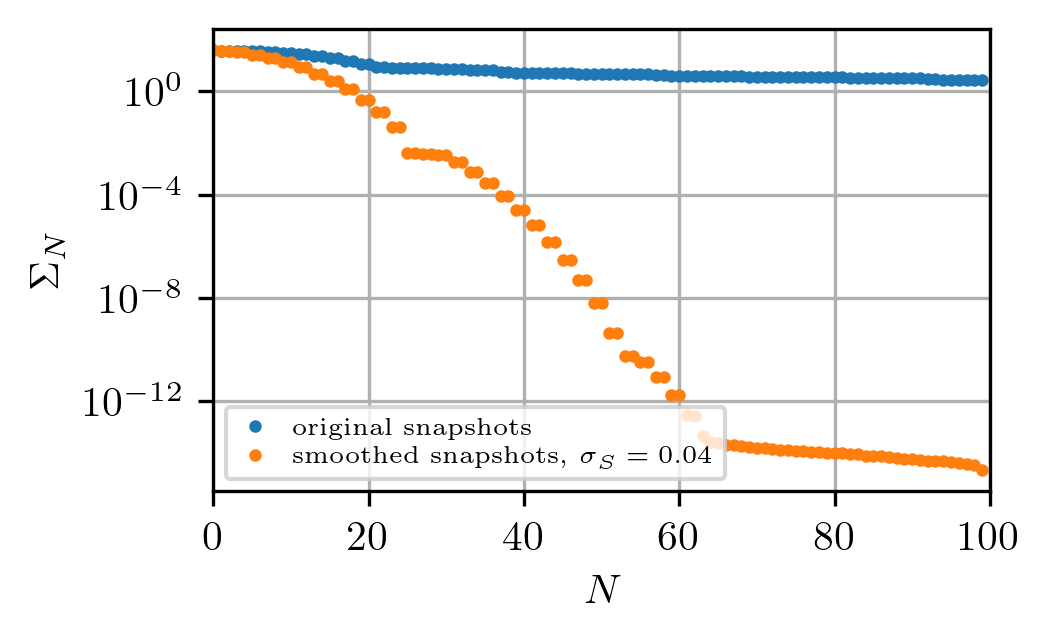

In [6]:
#Xe, Xs = get_data_rw(mu=np.linspace(0, 1, n_x, endpoint=False), sigma=case["sigma"], g=case["g"], x=case["x"])
Xe = snapshots_rowwise(case["g"], case["x"], mu=np.linspace(0, 1, n_x, endpoint=False))
Ue, Se, VT = np.linalg.svd(Xe.T, full_matrices=False)

X, Xs = get_data_rw(mu=np.linspace(0, 1, 100, endpoint=False), sigma=case["sigma"], g=case["g"], x=case["x"])
U1, S1, VT = np.linalg.svd(X.T, full_matrices=False)
U2, S2, VT = np.linalg.svd(Xs.T, full_matrices=False)



fig, ax = plt.subplots()
ax.plot(np.arange(len(S1)), S1, "C0o", ms=2, lw=0, label="original snapshots")
ax.plot(np.arange(len(S2)), S2, "C1o", ms=2, lw=0, label=r"smoothed snapshots, $\sigma_S=0.04$")
#ax.plot(np.arange(len(Se)), Se, "C2>-", ms=2, lw=1, label="exact basis, truncated")

#ax.plot(np.arange(len(S)), S, "C1-", ms=1, label="rectangular pulse")
# ax.plot(delta_N4, "C3-", ms=1, label="moving average smoothing")
# ax.plot(delta_N2, "C1-", ms=1, label="smoothed, $\sigma=0.005$")
# ax.plot(delta_N3, "C2-", ms=1, label="smoothed, $\sigma=0.01$")
# ax.plot(1/np.pi*np.arange(len(S))**(-1/2), "k--")
ax.set_yscale('log')
ax.set_xlim([0, 100])
#ax.set_ylim([.05, .1])
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\Sigma_N$")
plt.legend()
plt.tight_layout()
plt.savefig(pth+"SV_v2.pdf")
plt.show()

C:\Users\florianma\AppData\Local\Temp\8\ipykernel_96192\312407032.py:4: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(pth+"Pulse3D.pdf")


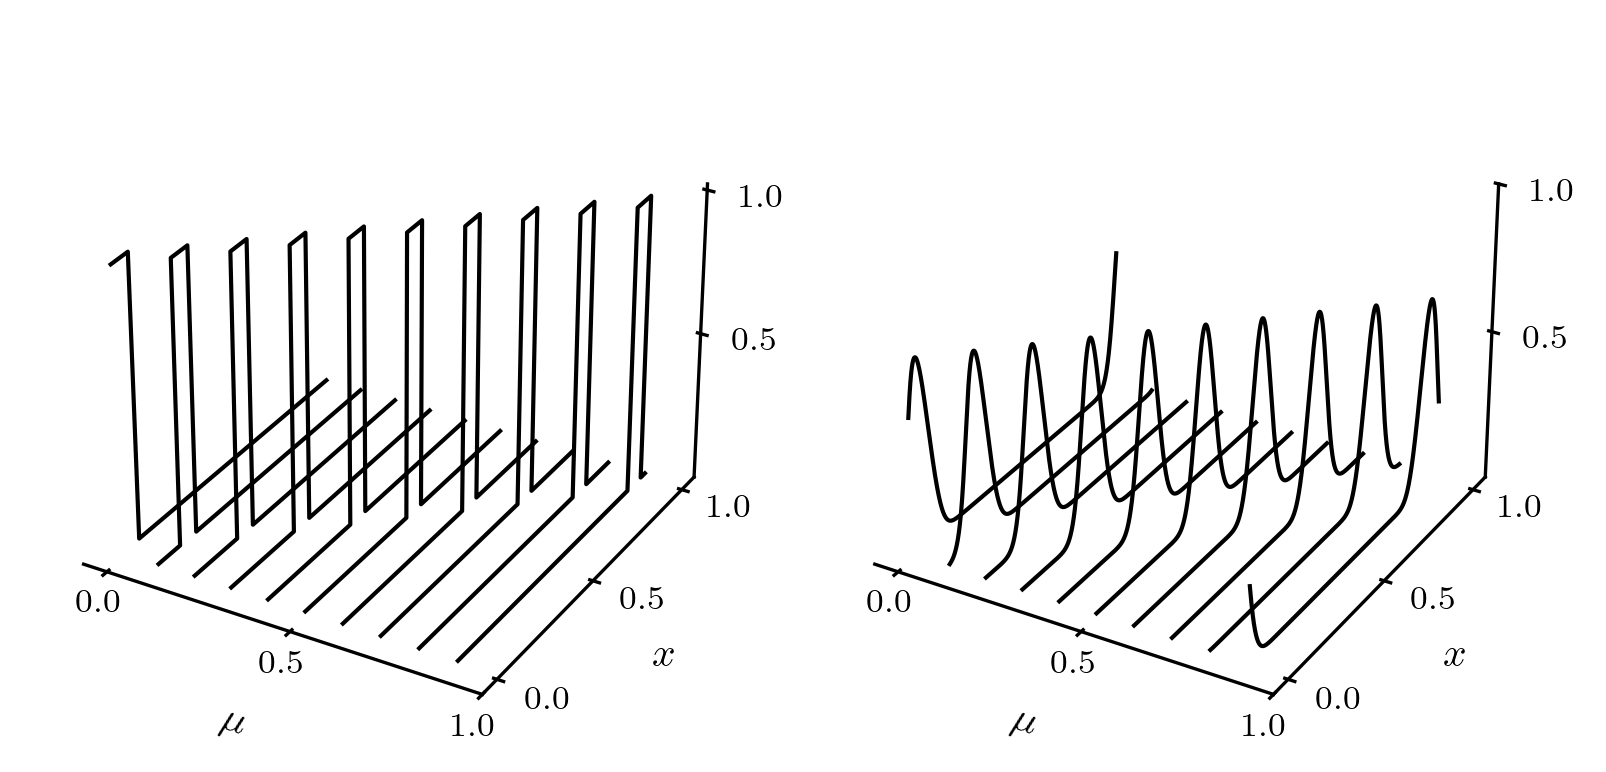

In [7]:
mu_train = np.linspace(0, 1, 10, endpoint=False)
X_train, X_train_s = get_data_rw(mu=mu_train, sigma=case["sigma"], g=case["g"], x=case["x"])
Fig3(x, mu_train.ravel(), X_train.T, X_train_s.T)
plt.savefig(pth+"Pulse3D.pdf")

In [8]:
# https://stats.stackexchange.com/a/211693
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10)])
#NN = np.array([10, 20, 50,100, 200, 500, 1000, 2000])
errors1 = np.zeros(NN.shape)
errors2 = np.zeros(NN.shape)
errors3 = np.zeros(NN.shape)
#errors4 = np.zeros(NN.shape)

# Xe = snapshots_rowwise(rectangular_pulse, x, mu=np.linspace(0, 1, n_x, endpoint=False))
# Xs = smoothen_rowwise(Xe, 0.008, x.shape)
_mu_tst = np.linspace(0, 1, n_x, endpoint=False)
Xe, Xs = get_data_rw(mu=_mu_tst, sigma=case["sigma"], g=case["g"], x=case["x"])
Ue1, S, VT = np.linalg.svd(Xe.T, full_matrices=False)
Ue2, S, VT = np.linalg.svd(Xs.T, full_matrices=False)

for i, n_ss in enumerate(NN):
    X = snapshots_rowwise(rectangular_pulse, x, mu=np.linspace(0, 1, n_ss, endpoint=False))
    Xs = smoothen_rowwise(X, 8, x.shape)
    X, Xs = get_data_rw(mu=np.linspace(0, 1, n_ss, endpoint=False), sigma=case["sigma"], g=case["g"], x=case["x"])
    U1, S, VT = np.linalg.svd(X.T, full_matrices=False)
    U2, S, VT = np.linalg.svd(Xs.T, full_matrices=False)

    U3 = Ue1[:, :n_ss]
    U4 = Ue2[:, :n_ss]
    print(U1.shape, U2.shape, U3.shape, U4.shape)

    approx1 = (U1 @ (U1.T @Xe.T)).T
    approx2 = (U2 @ (U2.T @Xe.T)).T
    approx3 = (U3 @ (U3.T @Xe.T)).T
    #approx4 = (U4 @ (U4.T @Xe.T)).T
    #approx2 = (U @ (U.T @X_s.T)).T

    errors1[i] = np.mean(np.mean((Xe-approx1)**2, axis=1)**.5)
    errors2[i] = np.mean(np.mean((Xe-approx2)**2, axis=1)**.5)
    errors3[i] = np.mean(np.mean((Xe-approx3)**2, axis=1)**.5)
   # errors4[i] = np.mean(np.mean((Xe-approx4)**2, axis=1)**.5)
   # print( np.mean(np.mean((Xe-approx1)**2, axis=1)**.5), np.mean(np.mean((Xe-approx2)**2, axis=1)**.5))


(2500, 3) (2500, 3) (2500, 3) (2500, 3)
(2500, 5) (2500, 5) (2500, 5) (2500, 5)
(2500, 7) (2500, 7) (2500, 7) (2500, 7)
(2500, 9) (2500, 9) (2500, 9) (2500, 9)
(2500, 11) (2500, 11) (2500, 11) (2500, 11)
(2500, 13) (2500, 13) (2500, 13) (2500, 13)
(2500, 15) (2500, 15) (2500, 15) (2500, 15)
(2500, 17) (2500, 17) (2500, 17) (2500, 17)
(2500, 19) (2500, 19) (2500, 19) (2500, 19)
(2500, 21) (2500, 21) (2500, 21) (2500, 21)
(2500, 23) (2500, 23) (2500, 23) (2500, 23)
(2500, 25) (2500, 25) (2500, 25) (2500, 25)
(2500, 30) (2500, 30) (2500, 30) (2500, 30)
(2500, 35) (2500, 35) (2500, 35) (2500, 35)
(2500, 40) (2500, 40) (2500, 40) (2500, 40)
(2500, 45) (2500, 45) (2500, 45) (2500, 45)
(2500, 50) (2500, 50) (2500, 50) (2500, 50)
(2500, 55) (2500, 55) (2500, 55) (2500, 55)
(2500, 60) (2500, 60) (2500, 60) (2500, 60)
(2500, 65) (2500, 65) (2500, 65) (2500, 65)
(2500, 70) (2500, 70) (2500, 70) (2500, 70)
(2500, 80) (2500, 80) (2500, 80) (2500, 80)
(2500, 90) (2500, 90) (2500, 90) (2500, 90)
(250

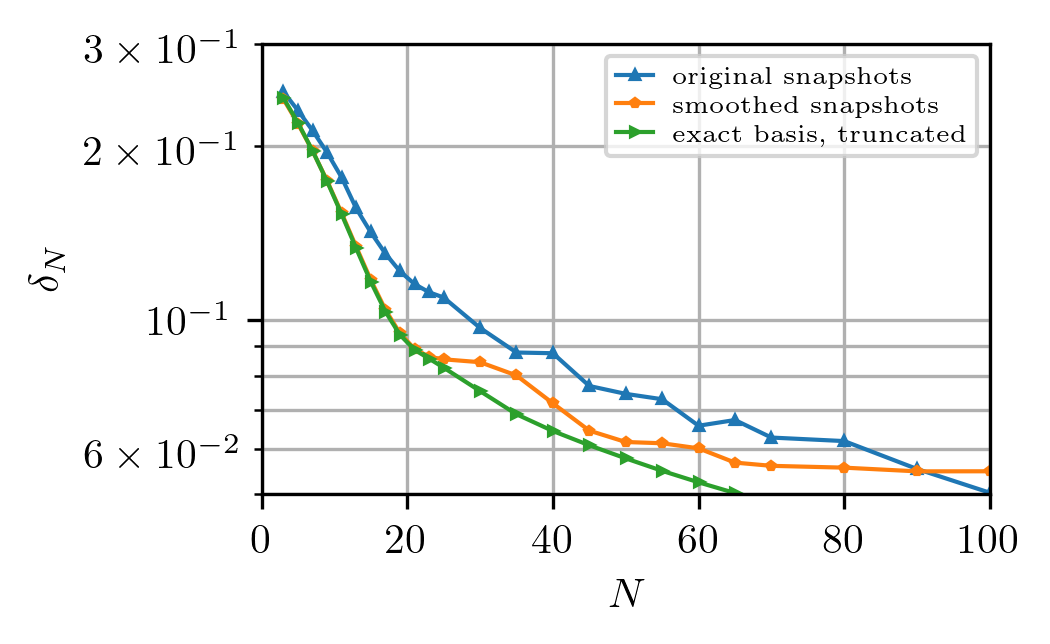

In [9]:
fig, ax = plt.subplots()
ax.plot(NN, errors1, "C0^-", ms=2, lw=1, label="original snapshots")
ax.plot(NN, errors2, "C1p-", ms=2, lw=1, label="smoothed snapshots")
ax.plot(NN, errors3, "C2>-", ms=2, lw=1, label="exact basis, truncated")

#ax.plot(np.arange(len(S)), S, "C1-", ms=1, label="rectangular pulse")
# ax.plot(delta_N4, "C3-", ms=1, label="moving average smoothing")
# ax.plot(delta_N2, "C1-", ms=1, label="smoothed, $\sigma=0.005$")
# ax.plot(delta_N3, "C2-", ms=1, label="smoothed, $\sigma=0.01$")
# ax.plot(1/np.pi*np.arange(len(S))**(-1/2), "k--")
ax.set_yscale('log')
ax.set_xlim([0, 100])
ax.set_ylim([.05, .3])
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\delta_N$")
plt.legend()
plt.tight_layout()
#plt.savefig(pth+"Pulse_smoothing_deltaN.pdf")
plt.show()

In [11]:
n_ss = 10
_mu_trn = np.linspace(0, 1, n_ss, endpoint=False)

X = snapshots_rowwise(rectangular_pulse, x, mu=_mu_trn)
Xs = smoothen_rowwise(X, 8, x.shape)
X, Xs = get_data_rw(mu=np.linspace(0, 1, n_ss, endpoint=False), sigma=case["sigma"], g=case["g"], x=case["x"])
U1, S, VT = np.linalg.svd(X.T, full_matrices=False)
U2, S, VT = np.linalg.svd(Xs.T, full_matrices=False)

U3 = Ue1[:, :n_ss]
U4 = Ue2[:, :n_ss]
print(U1.shape, U2.shape, U3.shape, U4.shape)

approx1 = (U1 @ (U1.T @Xe.T)).T  # standard ROM
approx2 = (U2 @ (U2.T @Xe.T)).T  # smooth ROM
approx3 = (U3 @ (U3.T @Xe.T)).T  # truncated, exact basis

my_ROM = train_ROM_rw(_mu_trn[:, None], X, rank=False)
my_sROM = train_ROM_rw(_mu_trn[:, None], Xs, rank=False)
my_eROM = train_ROM_rw(_mu_tst[:, None], Xe, rank=n_ss)

l = _mu_tst<=np.max(_mu_trn)
approx4 = my_ROM.predict(_mu_tst[l, None]).snapshots_matrix
approx5 = my_sROM.predict(_mu_tst[l, None]).snapshots_matrix
approx6 = my_eROM.predict(_mu_tst[l, None]).snapshots_matrix

(2500, 10) (2500, 10) (2500, 10) (2500, 10)


12.489995996796795
10.339457349884219
7.610042524308213
12.073797900606124
9.898928296744463
7.610042524308213


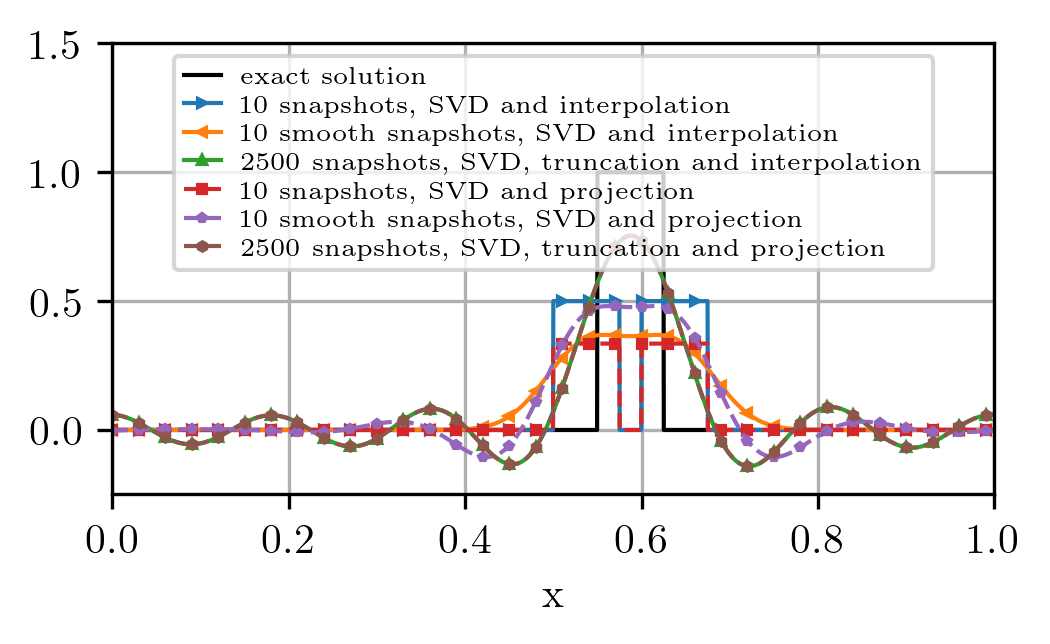

In [16]:
i = 5*250 +125
markevery = 75
print(np.sum((approx4[i]-Xe[i])**2)**.5)
print(np.sum((approx5[i]-Xe[i])**2)**.5)
print(np.sum((approx6[i]-Xe[i])**2)**.5)

print(np.sum((approx1[i]-Xe[i])**2)**.5)
print(np.sum((approx2[i]-Xe[i])**2)**.5)
print(np.sum((approx3[i]-Xe[i])**2)**.5)

fig, ax = plt.subplots()
ax.plot(x, Xe[i], "k-", ms=2, lw=1, label="exact solution")
ax.plot(x, approx4[i], "C0>-", ms=2, lw=1, label="10 snapshots, SVD and interpolation", markevery=markevery)
ax.plot(x, approx5[i], "C1<-", ms=2, lw=1, label="10 smooth snapshots, SVD and interpolation", markevery=markevery)
ax.plot(x, approx6[i], "C2^-", ms=2, lw=1, label="2500 snapshots, SVD, truncation and interpolation", markevery=markevery)


# ax.set_xlim([0, 1])
# ax.set_ylim([-0.25, 1.5])
# plt.grid(which="minor")
# plt.grid(which="major")
# ax.set_xlabel(r"x")
# #ax.set_ylabel(r"$\delta_N$")
# plt.legend(loc="upper center")
# plt.tight_layout()
# plt.savefig(pth+"approximations1.pdf")
# plt.show()
# fig, ax = plt.subplots()
# ax.plot(x, Xe[i], "k-", ms=2, lw=1, label="exact solution")


ax.plot(x, approx1[i], "C3s--", ms=2, lw=1, label="10 snapshots, SVD and projection", markevery=(0, markevery))
ax.plot(x, approx2[i], "C4p--", ms=2, lw=1, label="10 smooth snapshots, SVD and projection", markevery=(0, markevery))
ax.plot(x, approx3[i], "C5h--", ms=2, lw=1, label="2500 snapshots, SVD, truncation and projection", markevery=(0, markevery))


ax.set_xlim([0, 1])
ax.set_ylim([-0.25, 1.5])
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlabel(r"x")
#ax.set_ylabel(r"$\delta_N$")
plt.legend(loc="upper center")
plt.tight_layout()
plt.savefig(pth+"approximations.pdf")
plt.show()

In [12]:
m, n = 2500, 2500
# w = 30  # width of the pulse in # nodes
x = np.linspace(0, 1, m, endpoint=False)+1/(2*m)
mu_train = np.linspace(0.0, 1.0, n, endpoint=False)+1/(2*n)
# mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])
# mu_validation = np.linspace(0, 1, m, endpoint=False)
sigma = 0.05
mode = "constant"
rank = 10
dx = 1/m
#pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
pth = "../Plots/"


X_train = np.empty((m, len(mu_train)))
X_train_s1 = np.empty((m, len(mu_train)))
X_train_s2 = np.empty((m, len(mu_train)))
X_train_s3 = np.empty((m, len(mu_train)))
X_train_s4 = np.empty((m, len(mu_train)))
X_train_s5 = np.empty((m, len(mu_train)))


def test1():
    sigma = 0.05
    mu = 0.25
    x = np.linspace(0, 1, 101, endpoint=False)
    dx = x[1]-x[0]
    y = pulse(x, mu)
    g_x = gaussian(x-0.5+dx, sigma, shift=False)
    g_f = gaussian_f(x, sigma)
    ys1 = convolve_f(y, g_f)
    # ! boundary effects cant be avoided!
    ys2 = np.convolve(y, g_x, mode="same")
    ys3 = gaussian_filter(y, sigma=sigma/dx, truncate=12, mode="wrap")
    print(np.allclose(ys1, ys2, atol=1e-6))
    print(np.allclose(ys1, ys3, atol=1e-6))
    print(np.allclose(ys2, ys3, atol=1e-6))
    plt.plot(x, y, "C0.")
    plt.plot(x, ys1, "C1.")
    plt.plot(x, ys2, "C2.")
    plt.plot(x, ys3, "C3.")
    return

In [13]:
n1 = int(0.05*m)
ma1 = np.ones(n1,)/n1

for j, mu_j in enumerate(mu_train):
    y = rectangular_pulse(x, mu_j, w=0.075-1e-6, periodic=False)
    X_train[:, j] = y
    X_train_s1[:, j] = gaussian_filter(y, sigma=0.005/dx, truncate=12, mode="wrap")
    X_train_s2[:, j] = gaussian_filter(y, sigma=0.02/dx, truncate=12, mode="wrap")
    X_train_s3[:, j] = np.convolve(y, ma1, mode="same")

U1, S1, VT = np.linalg.svd(X_train, False)
U2, S2, VT = np.linalg.svd(X_train_s1, False)
U3, S3, VT = np.linalg.svd(X_train_s2, False)
U4, S4, VT = np.linalg.svd(X_train_s3, False)
delta_N1 = delta_n_width(S1, m, n)
delta_N2 = delta_n_width(S2, m, n)
delta_N3 = delta_n_width(S3, m, n)
delta_N4 = delta_n_width(S4, m, n)

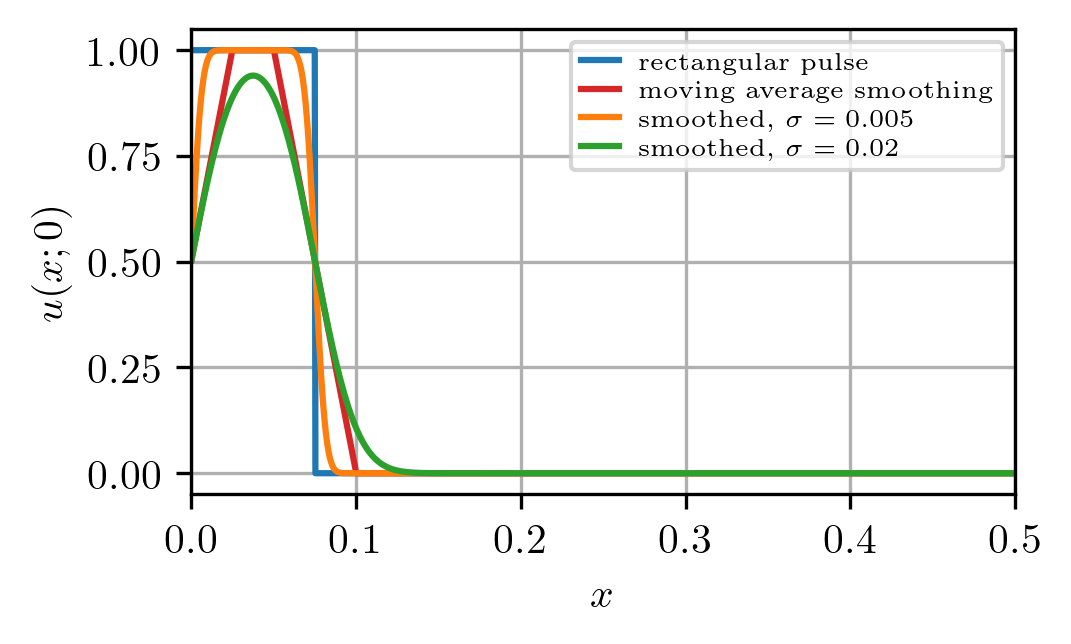

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_357052\640488033.py:19: RuntimeWarning: divide by zero encountered in power
  plt.plot(delta_N1 / (1/np.pi*np.arange(len(S1))**(-1/2)), ".")


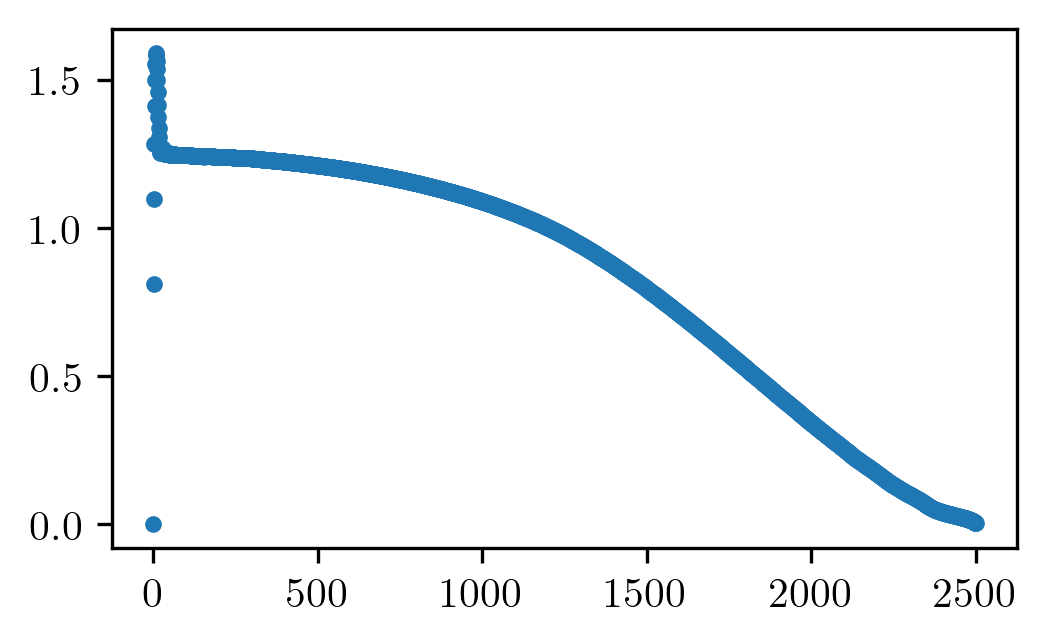

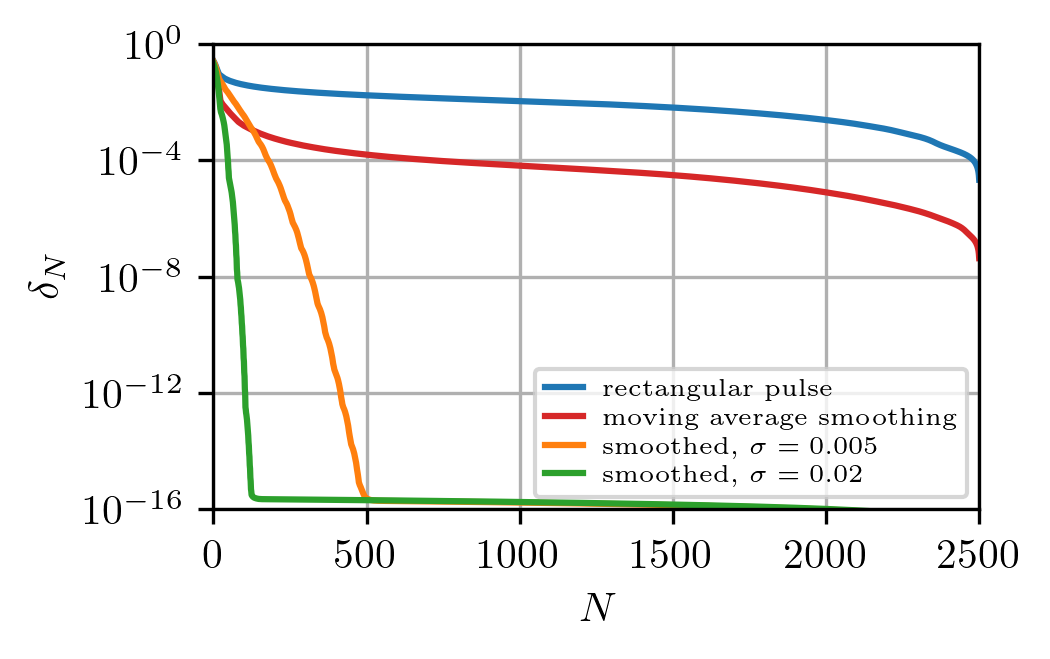

In [14]:
nss = 0
fig, ax = plt.subplots()
ax.plot(x, X_train[:, nss], "C0-", label="rectangular pulse")
ax.plot(x, X_train_s3[:, nss], "C3-", label="moving average smoothing")
ax.plot(x, X_train_s1[:, nss], "C1-", label=r"smoothed, $\sigma=0.005$")
ax.plot(x, X_train_s2[:, nss], "C2-", label=r"smoothed, $\sigma=0.02$")
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlim([0.0, .5])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x; 0)$")
plt.legend()
plt.tight_layout()
plt.savefig(pth+"Pulse_smoothing.pdf")
plt.show()

fig, ax = plt.subplots()
plt.plot(delta_N1 / (1/np.pi*np.arange(len(S1))**(-1/2)), ".")
plt.show()

fig, ax = plt.subplots()
ax.plot(delta_N1, "C0-", ms=1, label="rectangular pulse")
ax.plot(delta_N4, "C3-", ms=1, label="moving average smoothing")
ax.plot(delta_N2, "C1-", ms=1, label=r"smoothed, $\sigma=0.005$")
ax.plot(delta_N3, "C2-", ms=1, label=r"smoothed, $\sigma=0.02$")
# ax.plot(1/np.pi*np.arange(len(S))**(-1/2), "k--")
ax.set_yscale('log')
ax.set_xlim([0, len(S1)])
ax.set_ylim([1e-16, 1])
plt.grid(which="minor")
plt.grid(which="major")
ax.set_xlabel("$N$")
ax.set_ylabel(r"$\delta_N$")
plt.legend()
plt.tight_layout()
plt.savefig(pth+"Pulse_smoothing_deltaN.pdf")
plt.show()

In [15]:
# def pulseHWS(x, mu, w=0.1+1e-6):
#     y = np.zeros_like(x, dtype=np.float64)
#     y[((0+1e-6) < (x-mu)) & ((x-mu) < (w-1e-6))] = 1.0
#     mu2 = mu+1
#     y[((0+1e-6) < (x-mu2)) & ((x-mu2) < (w-1e-6))] = -1.0
#     mu3 = mu-1
#     y[((0+1e-6) < (x-mu3)) & ((x-mu3) < (w-1e-6))] = -1.0
#     mu4 = mu-2
#     y[((0+1e-6) < (x-mu4)) & ((x-mu4) < (w-1e-6))] = 1.0
#     return y

# from smooth_POD_ROM.pre_processing import smoothen
# from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width

0.0002 0.9998
1.0002 1.0002
mu
0.05 0.9500000000000001
0.05 1.0499999999999998
20
[15.8113883 15.8113883 15.8113883 15.8113883 15.8113883 15.8113883]
[15.64023282 15.08291132 14.32782155 13.09143335 11.99731585 10.36654164]
0.0002 0.9998
1.0002 1.0002
mu
0.03333333333333333 0.9666666666666667
0.03333333333333333 1.0333333333333332
30
[20.3268412  20.07141945 19.65027403 19.07018653 18.32974573 17.48153618]
[19.16763729 18.46274063 17.64192711 15.99067048 14.86730839 12.55692973]
0.0002 0.9998
1.0002 1.0002
mu
0.02 0.98
0.02 1.02
50
[25.38810811 25.06898593 24.5432511  23.82004393 22.91204111 21.83535098]
[24.73668061 23.82399691 22.71553572 20.60418041 19.10354735 16.13831709]
0.0002 0.9998
1.0002 1.0002
mu
0.0004 0.9996
0.0004 1.0004
2500
[176.04412166 173.85813129 170.25370266 165.28842838 159.04147837
 151.61219005]
[174.88169776 168.4143272  160.38886384 145.53821604 134.69230219
 113.86114505]


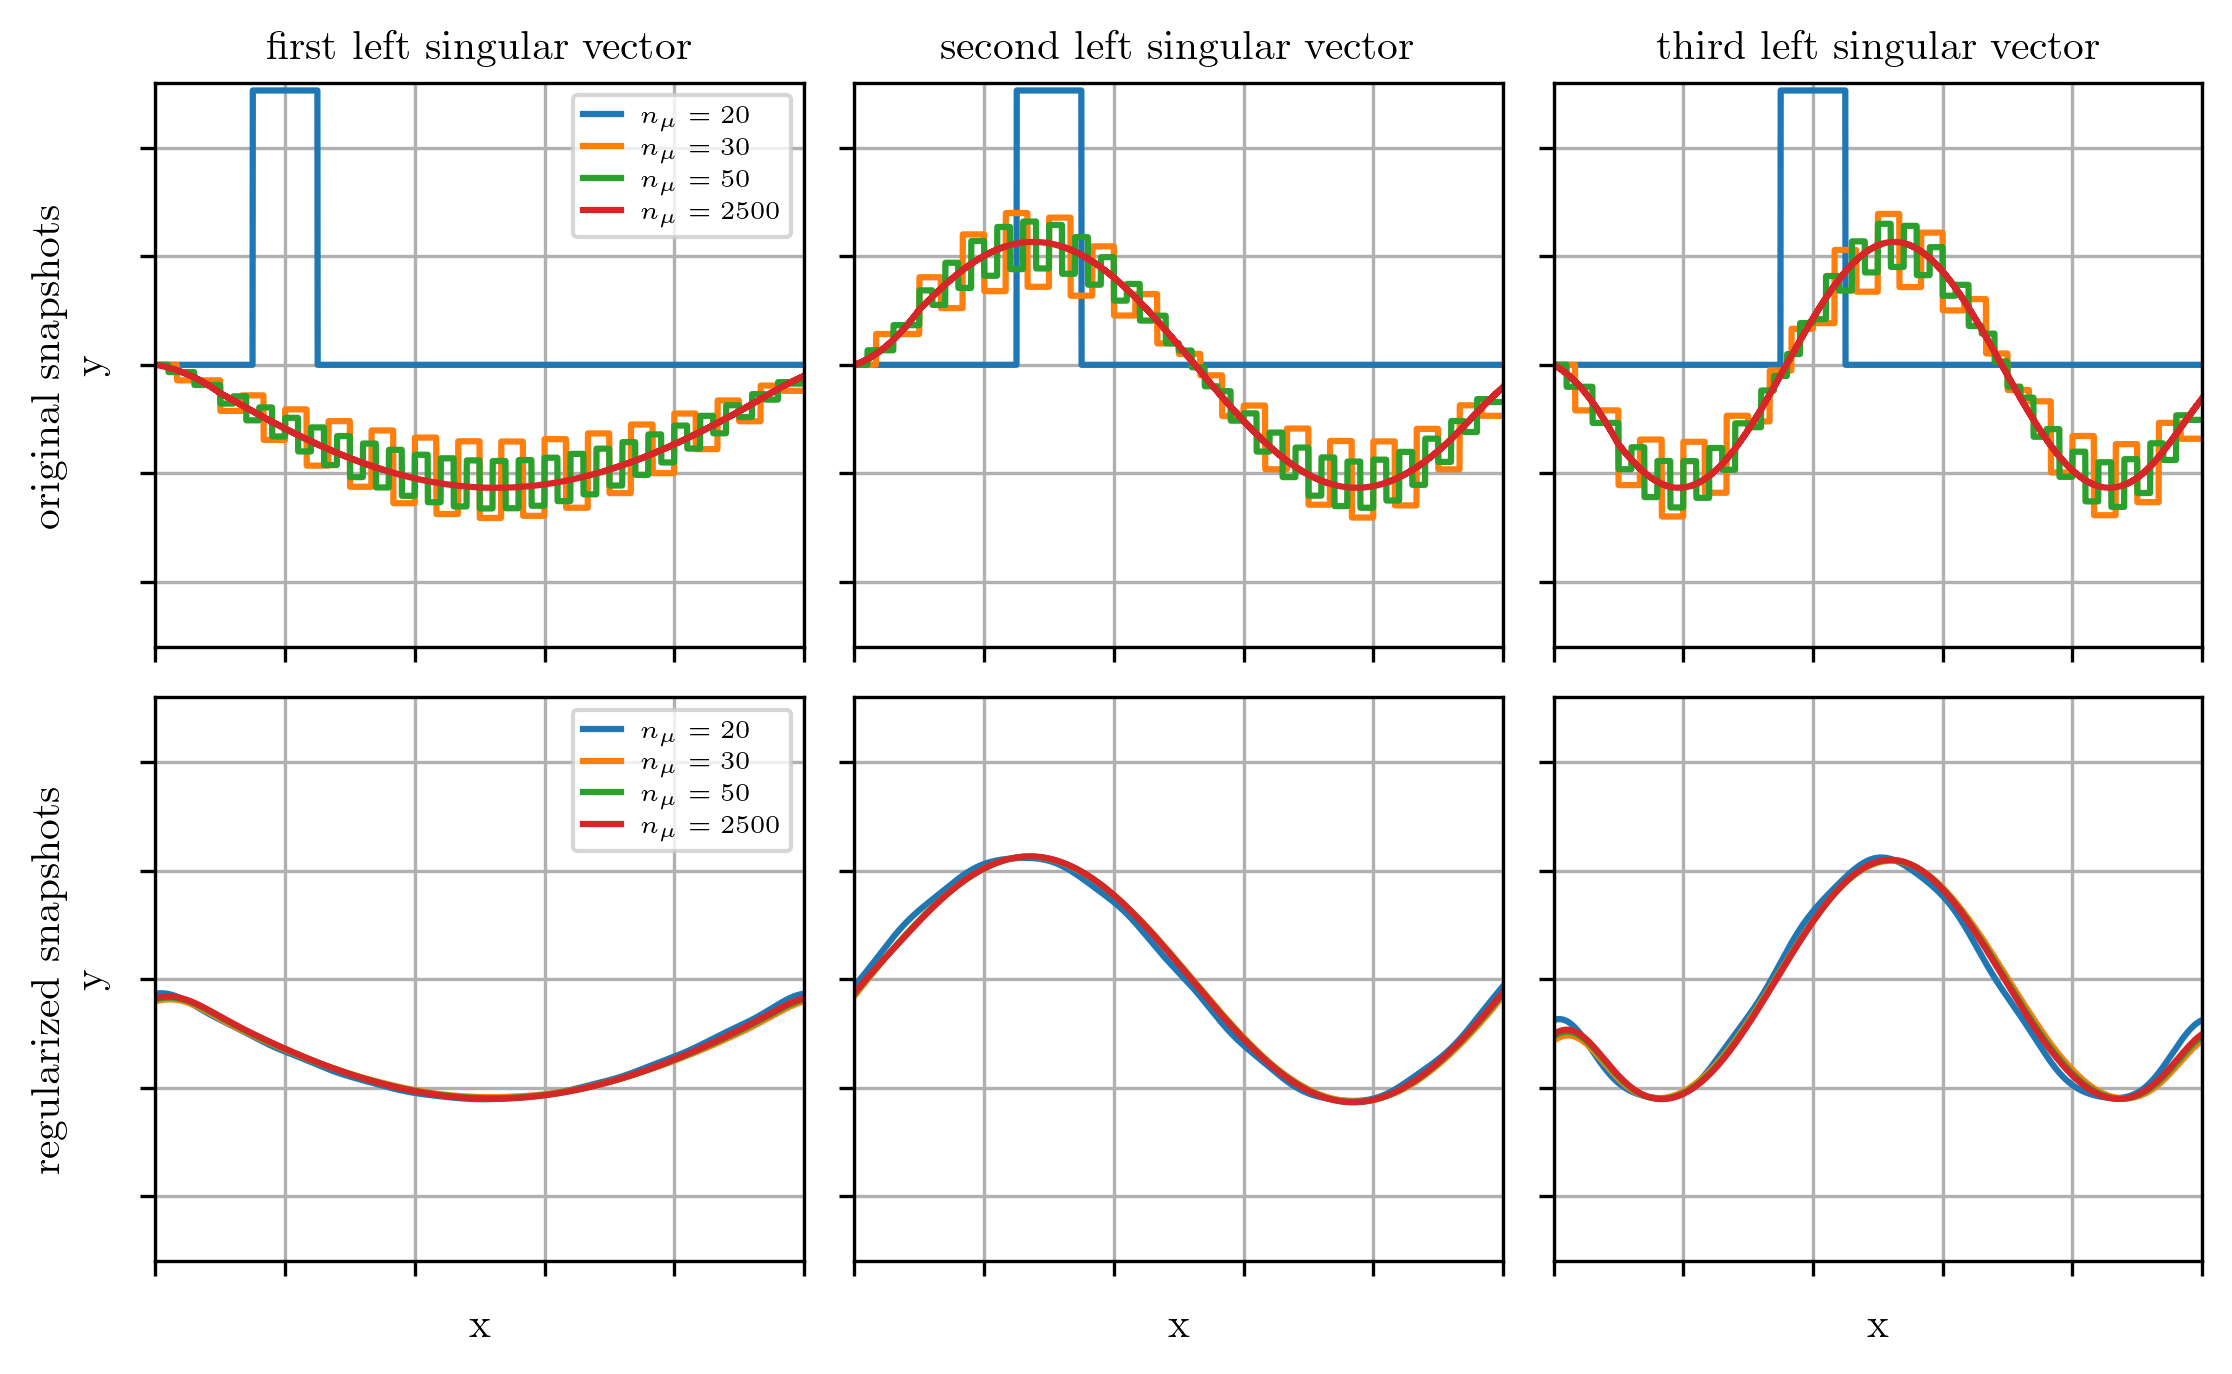

In [20]:
# m = 600
HWS = False
fig, axs = plt.subplots(2, 3, figsize=full_width_figure)
i = 0
for n in [20, 30, 50, m]:
    x = np.linspace(0, 1, m, endpoint=False) + 1/2*(1/m)
    mu = np.linspace(0, 1, n//2, endpoint=False) + 1/2*(2/n)
    print(x[0], x[-1])
    print(x[0]-(-1), 2-x[-1])
    print("mu")
    print(mu[0], mu[-1])
    print(mu[0], 2-mu[-1])
    print(n)
    
    X = np.zeros((m, n//2))
    Xs = np.zeros((m, n//2))
    for j, mu_j in enumerate(mu):
        y = rectangular_pulse(x, mu_j, w=0.1-1e-6, periodic=False)
        Xs[:, j] = gaussian_filter(y, sigma=0.04/dx, truncate=12, mode="wrap")  # 0.05 or 0.005
        X[:, j] = y

    dx = 1/m
    Ug, Sg, Vg = np.linalg.svd(X, full_matrices=False)
    Us, Ss, Vs = np.linalg.svd(Xs, full_matrices=False)
    print(Sg[:6])
    print(Ss[:6])

    Ug[:, np.mean(Ug[m//2:, :], axis=0)>=0] *= -1
    Us[:, np.mean(Us[m//2:, :], axis=0)>=0] *= -1
    for j in range(3):
        axs[0, j].plot(x, Ug[:, j], "C"+str(i)+"-", ms=1, label=r"$n_{\mu}=%i$"%n)
        axs[1, j].plot(x, Us[:, j], "C"+str(i)+"-", ms=1, label=r"$n_{\mu}=%i$"%n)
    i += 1
for i, ax in enumerate(axs.ravel()):
    #ax.set_xticks(np.linspace(-1., 1., 21, endpoint=True), minor=True)
    #ax.set_yticks(np.linspace(-.2, .2, 21, endpoint=True), minor=True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False, which='minor')
    ax.grid(True, which='major', linestyle='-')
    ax.set_xlim(-0.0, 1.0)
    ax.set_ylim(-0.065, 0.065)
axs[0, 0].legend()
axs[1, 0].legend()

axs[0, 0].set_ylabel(r"original snapshots \n y")
axs[1, 0].set_ylabel(r"regularized snapshots \n y")
axs[1, 0].set_xlabel("x")
axs[1, 1].set_xlabel("x")
axs[1, 2].set_xlabel("x")

axs[0, 0].set_title("first left singular vector")
axs[0, 1].set_title("second left singular vector")
axs[0, 2].set_title("third left singular vector")
plt.savefig(pth+"leftSV.pdf")
plt.show()